Crop Recommendation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Tuple
from sklearn.model_selection import train_test_split

from __future__ import annotations

from typing import Dict, Any

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [ ]:
df = pd.read_csv('Crop_District_Level.csv')

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,district
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,ryk
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,bahawalnagar
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,bwp
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,rajanpur
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,digikhan


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
 8   district     2200 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 154.8+ KB


#### defining features X and target y

In [ ]:
# defining features X and target y


FEATURE_COLUMNS: list[str] = ["N","P","K","temperature","humidity","ph","rainfall",]

TARGET_COLUMN: str = "label"

X: pd.DataFrame = df[FEATURE_COLUMNS]
y: pd.Series = df[TARGET_COLUMN]


#### train test split

In [ ]:

# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y,
)

print("training X_train ", X_train.shape)
print("testing X_test", X_test.shape)

print("training y_train", y_train.shape)
print("testing y_test ", y_test.shape)

training X_train  (1760, 7)
testing X_test (440, 7)
training y_train (1760,)
testing y_test  (440,)


In [ ]:

from sklearn.base import ClassifierMixin
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

model benchmarking

In [ ]:
# benchmark models


models: Dict[str, ClassifierMixin] = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42,
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
    ),

    "KNN": KNeighborsClassifier(),

    "SVM (RBF)": SVC(
        kernel="rbf",
        random_state=42,
    ),
}

train bench models

In [ ]:
# models training

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy,
        }
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


models results

In [ ]:
# model results

benchmark_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

benchmark_df

,Model,Accuracy
0,Random Forest,0.993182
1,Extra Trees,0.986364
2,Decision Tree,0.984091
3,KNN,0.972727
4,SVM (RBF),0.956818
5,Logistic Regression,0.865909


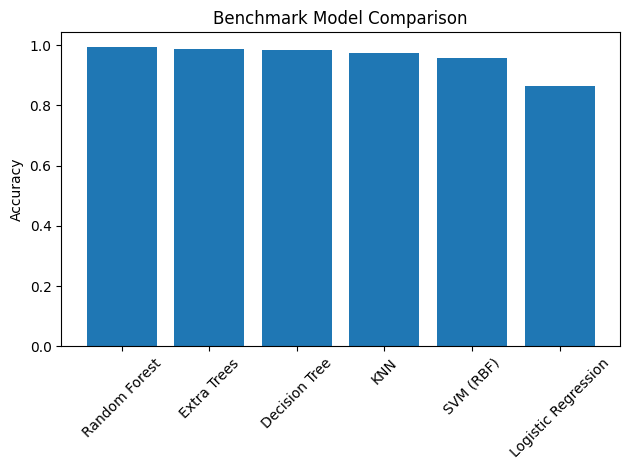

In [ ]:
# histogram of model results


plt.bar(
    benchmark_df["Model"],
    benchmark_df["Accuracy"],
)

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Benchmark Model Comparison")
plt.tight_layout()
plt.show()

checking other metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_all_metrics = []

top_3_models = ["Random Forest", "Extra Trees", "Decision Tree"]

for name, model in models.items():
    if name in top_3_models:
        # Ensure the model is fitted if it wasn't already in a previous run
        if not hasattr(model, 'predict'):
            model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        accuracy = accuracy_score(y_test, predictions)
        macro_precision = precision_score(y_test, predictions, average='macro', zero_division=0)
        macro_recall = recall_score(y_test, predictions, average='macro', zero_division=0)
        macro_f1 = f1_score(y_test, predictions, average='macro', zero_division=0)

        results_all_metrics.append(
            {
                "Model": name,
                "Accuracy": accuracy,
                "Macro Precision": macro_precision,
                "Macro Recall": macro_recall,
                "Macro F1": macro_f1,
            }
        )

metrics_df = (
    pd.DataFrame(results_all_metrics)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

print("Model Evaluation Metrics for Top 3 Models:")
display(metrics_df)

Model Evaluation Metrics for Top 3 Models:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.993182,0.995506,0.994872,0.995172
1,Decision Tree,0.984091,0.988006,0.989103,0.988414
2,Extra Trees,0.986364,0.989381,0.985897,0.987350


checking cross validation

In [ ]:

from sklearn.base import ClassifierMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [ ]:
top_models: Dict[str, ClassifierMixin] = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
}

In [ ]:
# 10 fold cross validation

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42,
)

cv_results = []

for name, model in top_models.items():

    scores = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
    )

    cv_results.append(
        {
            "Model": name,
            "Mean Macro F1": scores.mean(),
            "Std": scores.std(),
            "Minimum": scores.min(),
            "Maximum": scores.max(),
        }
    )

cv_df = (
    pd.DataFrame(cv_results)
    .sort_values("Mean Macro F1", ascending=False)
    .reset_index(drop=True)
)

cv_df

,Model,Mean Macro F1,Std,Minimum,Maximum
0,Random Forest,0.995405,0.003592,0.989789,1.0
1,Extra Trees,0.994892,0.003832,0.989313,1.0
2,Decision Tree,0.986725,0.008172,0.972005,1.0


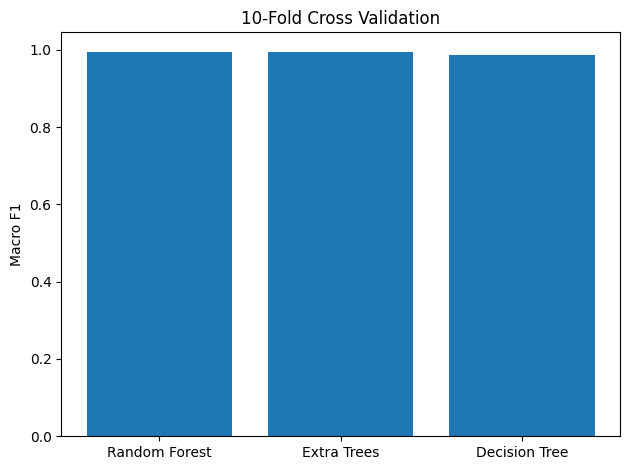

In [ ]:
plt.bar(cv_df["Model"],cv_df["Mean Macro F1"],)

plt.ylabel("Macro F1")
plt.title("10-Fold Cross Validation")

plt.tight_layout()
plt.show()

classification matrix

In [ ]:
from sklearn.base import ClassifierMixin
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    matthews_corrcoef,
)

In [ ]:
def evaluate_model(
    model: ClassifierMixin,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    model_name: str,
) -> pd.DataFrame:
    """
    Evaluate a trained classification model.

    Parameters
    ----------
    model : ClassifierMixin
        Trained classification model.

    X_test : pd.DataFrame
        Test feature matrix.

    y_test : pd.Series
        True labels.

    model_name : str
        Name of the model.

    Returns
    -------
    pd.DataFrame
        Classification report as a DataFrame.
    """

    # ------------------------------------------------------------------
    # Generate predictions
    # ------------------------------------------------------------------

    predictions = model.predict(X_test)

    # ------------------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        predictions,
        normalize="true",
    )

    plt.figure(figsize=(11, 9))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=model.classes_,
        yticklabels=model.classes_,
    )

    plt.title(f"{model_name} - Normalized Confusion Matrix")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.xticks(rotation=45)

    plt.yticks(rotation=0)

    plt.tight_layout()

    plt.show()

    # ------------------------------------------------------------------
    # Classification Report
    # ------------------------------------------------------------------

    report = pd.DataFrame(
        classification_report(
            y_test,
            predictions,
            output_dict=True,
        )
    ).transpose()

    display(report)

    # ------------------------------------------------------------------
    # Additional Metrics
    # ------------------------------------------------------------------

    print(f"\n{model_name}")

    print("-" * len(model_name))

    print(f"Cohen's Kappa : {cohen_kappa_score(y_test, predictions):.4f}")

    print(f"Matthews CC   : {matthews_corrcoef(y_test, predictions):.4f}")

    return report

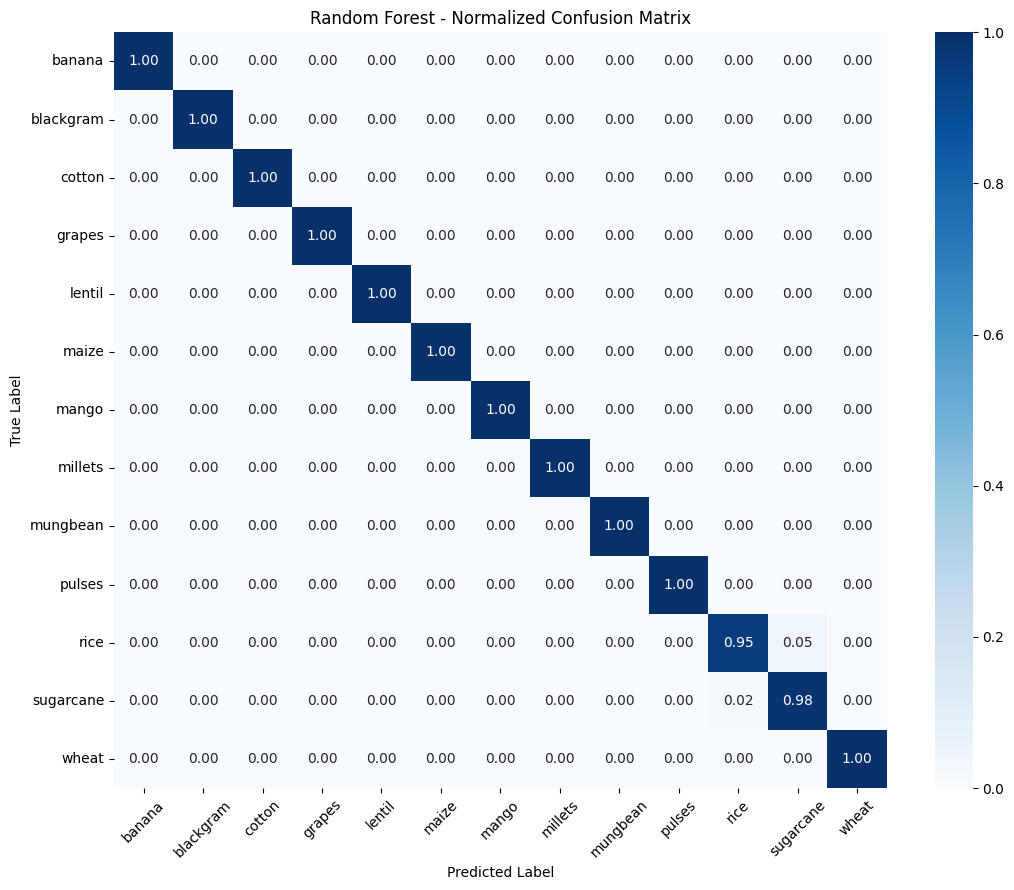

,precision,recall,f1-score,support
banana,1.000000,1.000000,1.000000,20.000000
blackgram,1.000000,1.000000,1.000000,20.000000
cotton,1.000000,1.000000,1.000000,60.000000
grapes,1.000000,1.000000,1.000000,20.000000
lentil,1.000000,1.000000,1.000000,20.000000
maize,1.000000,1.000000,1.000000,60.000000
mango,1.000000,1.000000,1.000000,20.000000
millets,1.000000,1.000000,1.000000,20.000000
mungbean,1.000000,1.000000,1.000000,20.000000
pulses,1.000000,1.000000,1.000000,20.000000



Random Forest
-------------
Cohen's Kappa : 0.9924
Matthews CC   : 0.9924


In [ ]:
rf_report = evaluate_model(
    model=models["Random Forest"],
    X_test=X_test,
    y_test=y_test,
    model_name="Random Forest",
)

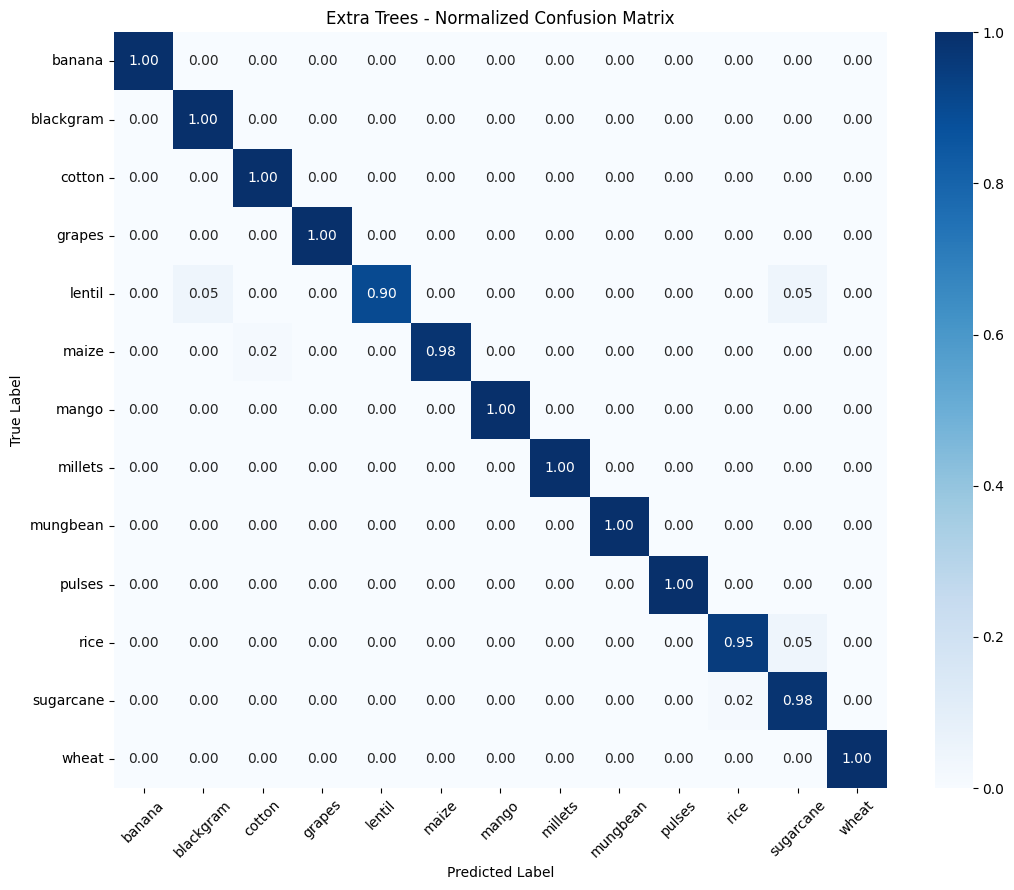

,precision,recall,f1-score,support
banana,1.000000,1.000000,1.000000,20.000000
blackgram,0.952381,1.000000,0.975610,20.000000
cotton,0.983607,1.000000,0.991736,60.000000
grapes,1.000000,1.000000,1.000000,20.000000
lentil,1.000000,0.900000,0.947368,20.000000
maize,1.000000,0.983333,0.991597,60.000000
mango,1.000000,1.000000,1.000000,20.000000
millets,1.000000,1.000000,1.000000,20.000000
mungbean,1.000000,1.000000,1.000000,20.000000
pulses,1.000000,1.000000,1.000000,20.000000



Extra Trees
-----------
Cohen's Kappa : 0.9849
Matthews CC   : 0.9849


In [ ]:
et_report = evaluate_model(
    model=models["Extra Trees"],
    X_test=X_test,
    y_test=y_test,
    model_name="Extra Trees",
)

In [ ]:
def plot_feature_importance(
    model,
    feature_names: list[str],
    model_name: str,
) -> pd.DataFrame:
    """
    Plot feature importance of a tree-based model.

    Parameters
    ----------
    model : Tree-based estimator
        Trained model having feature_importances_ attribute.

    feature_names : list[str]
        Predictor names.

    model_name : str
        Model name used in plot title.

    Returns
    -------
    pd.DataFrame
        Sorted feature importance table.
    """

    # ------------------------------------------------------------------
    # Create importance dataframe
    # ------------------------------------------------------------------

    importance_df = (
        pd.DataFrame(
            {
                "Feature": feature_names,
                "Importance": model.feature_importances_,
            }
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"],
    )

    plt.title(f"{model_name} Feature Importance")

    plt.xlabel("Importance Score")

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.show()

    return importance_df

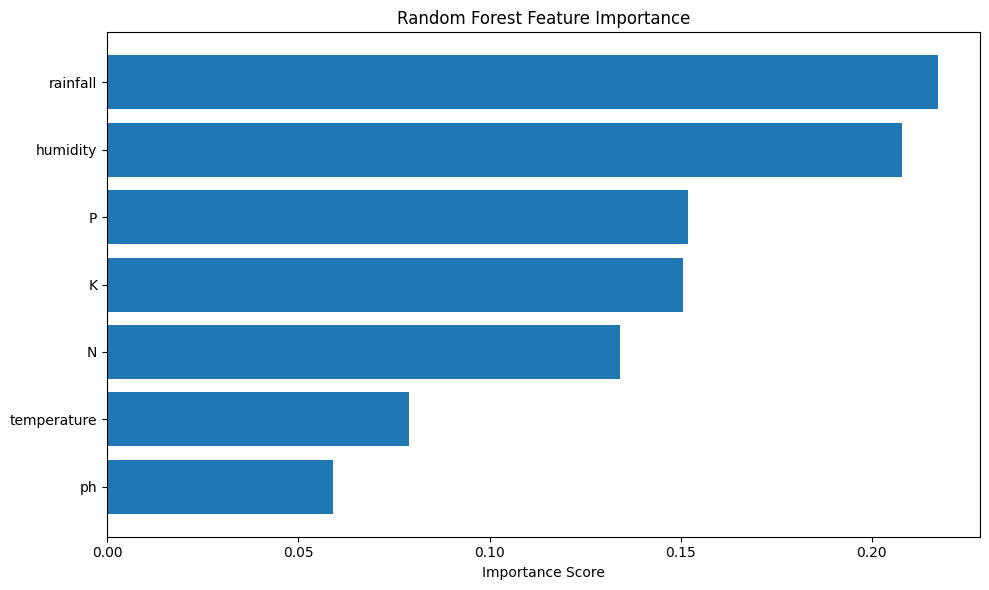

,Feature,Importance
0,rainfall,0.217397
1,humidity,0.207930
2,P,0.151977
3,K,0.150640
4,N,0.134115
5,temperature,0.078950
6,ph,0.058991


In [ ]:
rf_importance = plot_feature_importance(
    model=models["Random Forest"],
    feature_names=X_train.columns.tolist(),
    model_name="Random Forest",
)

rf_importance

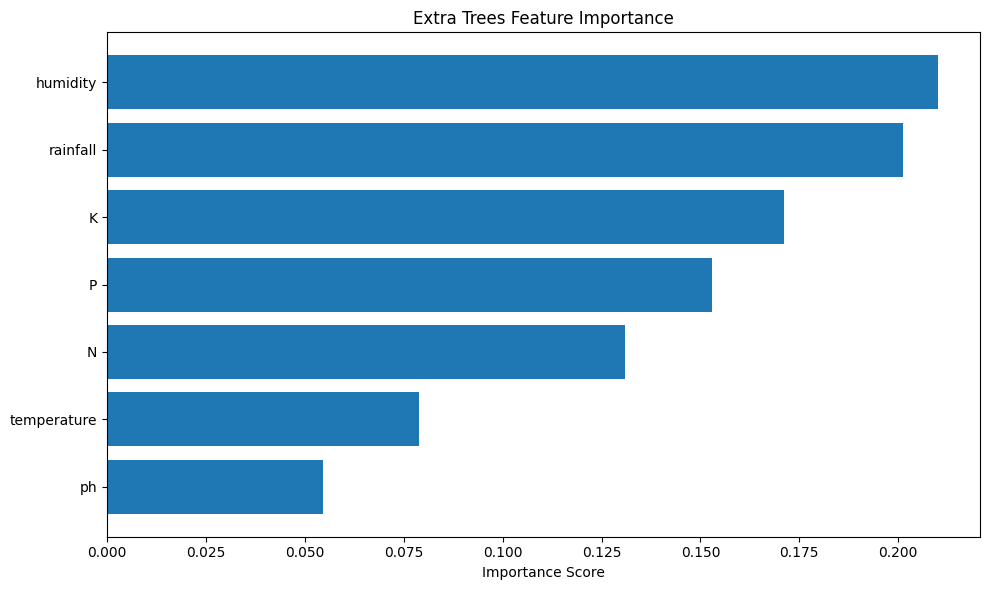

,Feature,Importance
0,humidity,0.210164
1,rainfall,0.201221
2,K,0.171157
3,P,0.153026
4,N,0.130949
5,temperature,0.078861
6,ph,0.054622


In [ ]:
et_importance = plot_feature_importance(
    model=models["Extra Trees"],
    feature_names=X_train.columns.tolist(),
    model_name="Extra Trees",
)

et_importance

In [ ]:
comparison_df = (
    rf_importance.rename(
        columns={"Importance": "Random Forest"}
    )
    .merge(
        et_importance.rename(
            columns={"Importance": "Extra Trees"}
        ),
        on="Feature",
    )
)

comparison_df

,Feature,Random Forest,Extra Trees
0,rainfall,0.217397,0.201221
1,humidity,0.207930,0.210164
2,P,0.151977,0.153026
3,K,0.150640,0.171157
4,N,0.134115,0.130949
5,temperature,0.078950,0.078861
6,ph,0.058991,0.054622


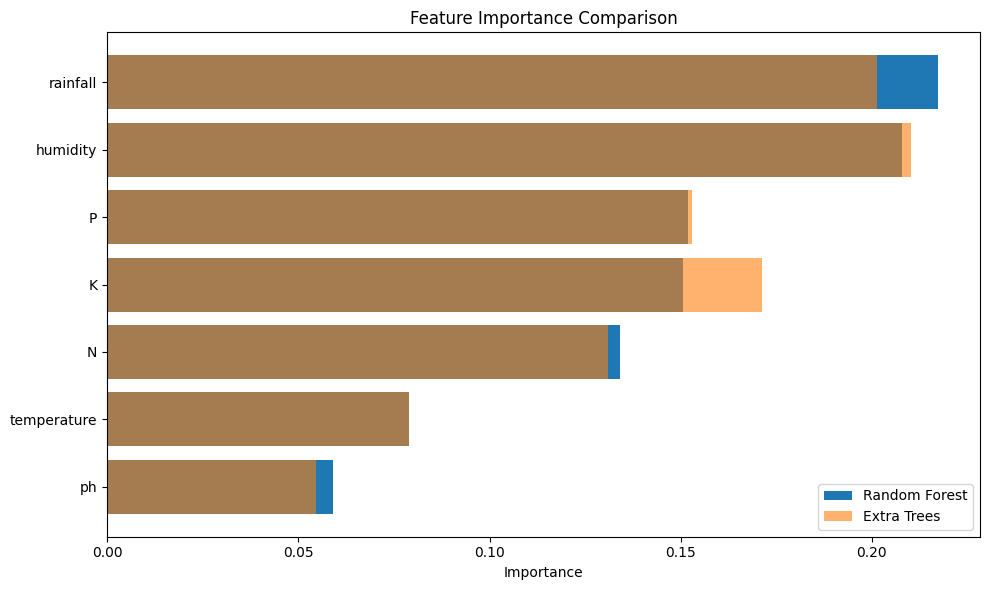

In [ ]:
comparison_df = comparison_df.sort_values(
    "Random Forest",
    ascending=True,
)

plt.figure(figsize=(10,6))

plt.barh(
    comparison_df["Feature"],
    comparison_df["Random Forest"],
    label="Random Forest",
)

plt.barh(
    comparison_df["Feature"],
    comparison_df["Extra Trees"],
    alpha=0.6,
    label="Extra Trees",
)

plt.legend()

plt.xlabel("Importance")

plt.title("Feature Importance Comparison")

plt.tight_layout()

plt.show()

permutation importance

In [ ]:
# ============================================================
# Permutation Feature Importance
# ============================================================

from sklearn.inspection import permutation_importance


def plot_permutation_importance(
    model,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    n_repeats: int = 20,
    random_state: int = 42
) -> Tuple[pd.DataFrame, object]:
    """
    Calculate and visualize permutation feature importance.

    Parameters
    ----------
    model : sklearn estimator
        Trained classification model.

    X_test : pd.DataFrame
        Test feature matrix.

    y_test : pd.Series
        Test target labels.

    n_repeats : int, default=20
        Number of shuffles for each feature.

    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    Tuple[pd.DataFrame, object]
        Feature importance dataframe and raw sklearn result object.
    """

    # Compute permutation importance
    result = permutation_importance(
        estimator=model,
        X=X_test,
        y=y_test,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring="f1_macro",
        n_jobs=-1
    )

    # Create dataframe
    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance Mean": result.importances_mean,
        "Importance Std": result.importances_std
    })

    # Sort descending
    importance_df = importance_df.sort_values(
        by="Importance Mean",
        ascending=False
    ).reset_index(drop=True)

    # Display table
    display(importance_df)

    # Plot
    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance Mean"],
        xerr=importance_df["Importance Std"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Mean Decrease in Macro F1")
    plt.ylabel("Feature")
    plt.title("Permutation Feature Importance")

    plt.tight_layout()
    plt.show()

    return importance_df, result

,Feature,Importance Mean,Importance Std
0,humidity,0.288399,0.025885
1,N,0.280581,0.022273
2,rainfall,0.184538,0.017015
3,K,0.116311,0.017116
4,P,0.114632,0.014962
5,ph,0.006583,0.003692
6,temperature,0.003606,0.002502


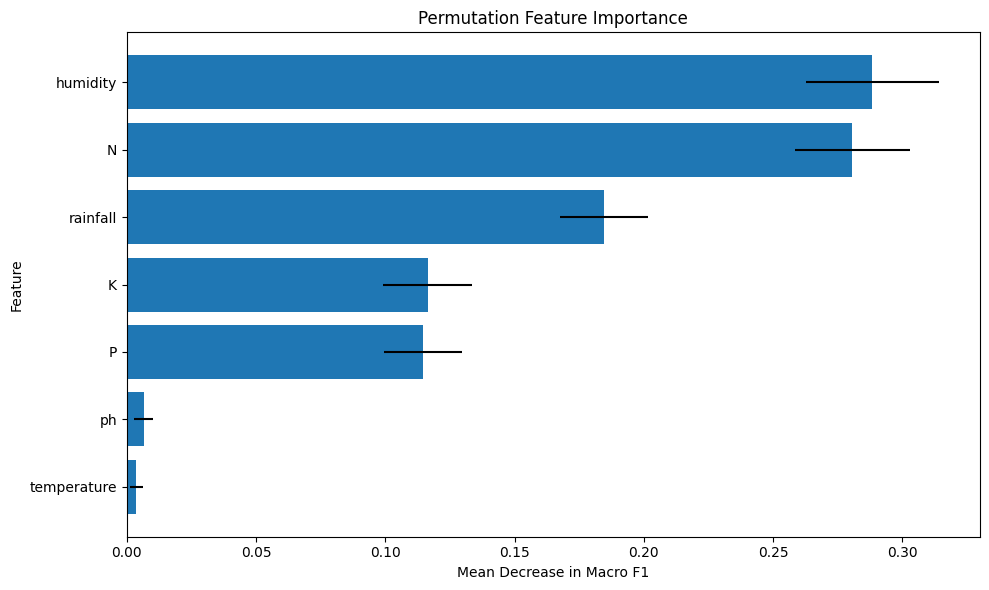

In [ ]:
rf_importance_df, rf_result = plot_permutation_importance(
    model=models["Random Forest"],
    X_test=X_test,
    y_test=y_test
)

In [ ]:
rf_importance_df

,Feature,Importance Mean,Importance Std
0,humidity,0.288399,0.025885
1,N,0.280581,0.022273
2,rainfall,0.184538,0.017015
3,K,0.116311,0.017116
4,P,0.114632,0.014962
5,ph,0.006583,0.003692
6,temperature,0.003606,0.002502


cross validation

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


# searching hyperparameters

param_distributions: Dict[str, Any] = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}



rf = RandomForestClassifier(
    random_state=42,
)


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=make_scorer(f1_score, average="macro"),
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True,
)


random_search.fit(X_train, y_train)


print("=" * 60)
print("Best Macro F1 Score:")
print(f"{random_search.best_score_:.4f}")

print("\nBest Hyperparameters:")
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")
print("=" * 60)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan]
  warnings.warn(


Best Macro F1 Score:
nan

Best Hyperparameters:
n_estimators: 400
min_samples_split: 2
min_samples_leaf: 2
max_features: log2
max_depth: 40
bootstrap: True


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# best model
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Test Accuracy : 0.9932

Classification Report
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        60
      grapes       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        60
       mango       1.00      1.00      1.00        20
     millets       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
      pulses       1.00      1.00      1.00        20
        rice       1.00      0.95      0.97        40
   sugarcane       0.95      1.00      0.98        60
       wheat       1.00      1.00      1.00        60

    accuracy                           0.99       440
   macro avg       1.00      0.99      0.99       440
weighted avg       0.99      0.99      0.99       440


Confusion Matrix
[[20  0  0  0  

testing with district column

In [ ]:
# copy of original dataset

df_with_district = df.copy()


# =============================================================================
# One-Hot Encode the district column
# =============================================================================

df_with_district = pd.get_dummies(
    df_with_district,
    columns=["district"],
    drop_first=False,
)


# =============================================================================
# Features and Target
# =============================================================================

X_district = df_with_district.drop(columns="label")
y_district = df_with_district["label"]


# =============================================================================
# Train-Test Split
# =============================================================================

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_district,
    y_district,
    test_size=0.20,
    stratify=y_district,
    random_state=42,
)

print(X_train_d.shape)
print(X_test_d.shape)

(1760, 46)
(440, 46)


In [ ]:


rf_district = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
)

rf_district.fit(X_train_d, y_train_d)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

pred_district = rf_district.predict(X_test_d)

accuracy = accuracy_score(y_test_d, pred_district)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_d,
    pred_district,
    average="macro",
)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1 Score  : {f1:.4f}")

Accuracy        : 0.9932
Macro Precision : 0.9963
Macro Recall    : 0.9923
Macro F1 Score  : 0.9942


In [ ]:
rf_metrics = metrics_df[metrics_df['Model'] == 'Random Forest'].iloc[0]

comparison_df = pd.DataFrame(
    {
        "Model": [
            "Without District",
            "With District",
        ],
        "Accuracy": [
            rf_metrics['Accuracy'],
            accuracy,
        ],
        "Macro Precision": [
            rf_metrics['Macro Precision'],
            precision,
        ],
        "Macro Recall": [
            rf_metrics['Macro Recall'],
            recall,
        ],
        "Macro F1": [
            rf_metrics['Macro F1'],
            f1,
        ],
    }
)

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Without District,0.993182,0.995506,0.994872,0.995172
1,With District,0.993182,0.996337,0.992308,0.994179


saving the model

In [ ]:
from pathlib import Path

# =============================================================================
# Create directory for saved artifacts
# =============================================================================

MODEL_DIR = Path("artifacts")
MODEL_DIR.mkdir(exist_ok=True)

print(MODEL_DIR.resolve())

/content/artifacts


In [ ]:
from pathlib import Path
import joblib

# =============================================================================
# Save the trained Random Forest model
# =============================================================================

MODEL_PATH = Path("artifacts/random_forest_crop_model.joblib")

joblib.dump(best_rf, MODEL_PATH)

print(f"Model saved successfully at:\n{MODEL_PATH.resolve()}")

Model saved successfully at:
/content/artifacts/random_forest_crop_model.joblib


In [ ]:
import joblib

loaded_model = joblib.load(MODEL_PATH)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
sample_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Predicted Crop :", sample_prediction[0])
print("Actual Crop    :", y_test.iloc[0])

Predicted Crop : sugarcane
Actual Crop    : sugarcane


In [ ]:
import joblib

FEATURES_PATH = Path("artifacts/feature_names.joblib")

joblib.dump(list(X_train.columns), FEATURES_PATH)

print("Feature names saved.")

Feature names saved.


In [ ]:
CLASS_NAMES_PATH = Path("artifacts/class_names.joblib")

joblib.dump(sorted(y.unique()), CLASS_NAMES_PATH)

print("Class names saved.")

Class names saved.


making inference

In [ ]:
from pathlib import Path
import numpy as np # Import numpy for array creation

# load models

ARTIFACTS_DIR = Path("artifacts")

model = joblib.load(ARTIFACTS_DIR / "random_forest_crop_model.joblib")
label_encoder = joblib.load(ARTIFACTS_DIR / "class_names.joblib")
feature_columns = joblib.load(ARTIFACTS_DIR / "feature_names.joblib")


# example input values

sample = {
    "N": 19,
    "P": 15,
    "K": 34,
    "temperature": 26.296449,
    "humidity": 99.658092,
    "ph": 5.685889,
    "rainfall": 215.919505,
}

# ------------------------------------------------------------------
# Create dataframe using the SAME feature order
# ------------------------------------------------------------------

input_df = pd.DataFrame([sample])

input_df = input_df[feature_columns]

# ------------------------------------------------------------------
# Prediction
# ------------------------------------------------------------------

# The model predicts the actual crop name (string) directly
actual_prediction_string = model.predict(input_df)[0]

# To get an "encoded" prediction (integer), find the index of the predicted string in the label_encoder list
prediction_encoded_value = label_encoder.index(actual_prediction_string)

# Assign the integer encoded value to prediction_encoded (as a single-element array)
prediction_encoded = np.array([prediction_encoded_value])

# The actual crop name is already available
prediction_crop = np.array([actual_prediction_string])

# ------------------------------------------------------------------
# Output
# ------------------------------------------------------------------

print("Encoded Prediction :", prediction_encoded[0])
print("Recommended Crop   :", prediction_crop[0])

Encoded Prediction : 2
Recommended Crop   : cotton


In [ ]:
df.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,label,district
584,20,50,22,30.996947,46.426937,9.406888,38.315979,sugarcane,gujranwala
1561,40,136,202,22.852674,94.576458,5.935336,117.531403,wheat,rawalpindi
2151,112,17,28,27.629755,61.260026,6.777418,196.649266,cotton,khanewal
846,2,79,15,21.535779,65.472277,7.505284,35.751076,lentil,multan
1814,19,15,34,26.296449,99.658092,5.685889,215.919505,cotton,kasur
